In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torchvision import transforms
import json
from src.config import *
from src.data_loader import load_dataframe, get_dataloaders, get_subset_loader
from src.model import create_model
from src.evaluate import evaluate_subset, plot_metrics, plot_confusion_matrix, visualize_model_predictions
from src.evaluate import plot_grad_cam

sns.set_style("whitegrid")
%matplotlib inline

print(f"Using device: {DEVICE}")
print(f"Model path: {MODEL_PATH}")

Using device: cpu
Model path: best_model_weights.pth


In [2]:
data_df = load_dataframe(DATA_PATH)
print(f"Total files found: {len(data_df)}")
print(f"Unique classes: {data_df['class_name'].unique()}")
data_df.head()


Total files found: 431
Unique classes: ['anchor' 'balloon' 'bicycle' 'envelope' 'paper_boat' 'peace_symbol'
 'smiley' 'speech_bubble' 'spiral' 'thumb']


,class_name,image_type,filepath
0,anchor,Hand-Drawn (Scanned/Digitalized),../dataset\anchor\digit01.jpg
1,anchor,Hand-Drawn (Scanned/Digitalized),../dataset\anchor\digit02.jpg
2,anchor,Hand-Drawn (Scanned/Digitalized),../dataset\anchor\digit03.jpg
3,anchor,Hand-Drawn (Scanned/Digitalized),../dataset\anchor\digit04.jpg
4,anchor,Hand-Drawn (Scanned/Digitalized),../dataset\anchor\digit05.jpg


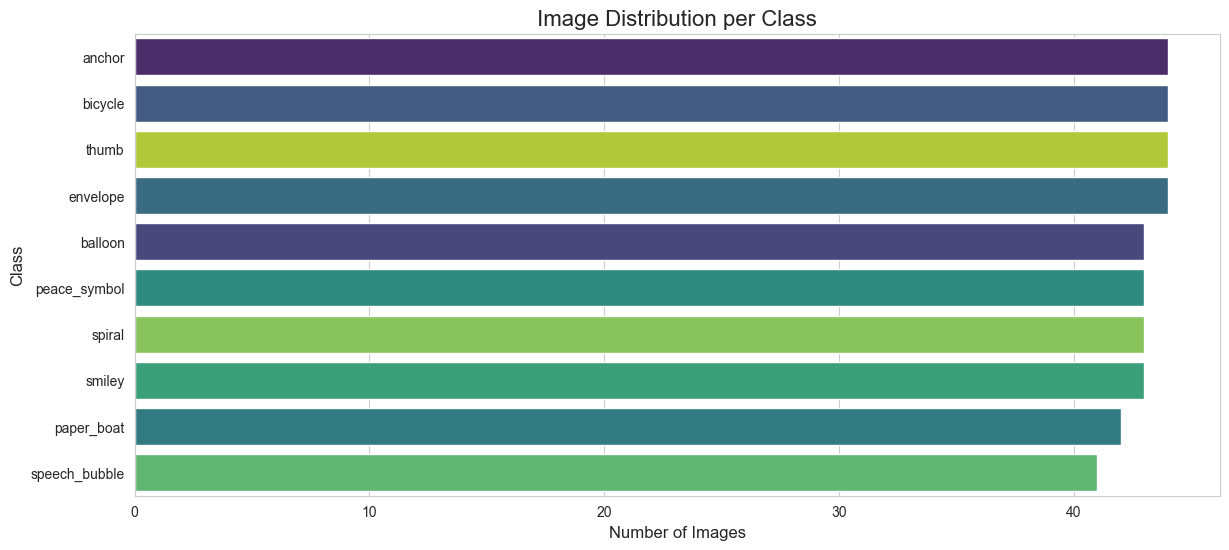

Conclusion: The dataset is very well balanced (41–44 images per class).


In [3]:
plt.figure(figsize=(14, 6))
sns.countplot(
    y="class_name",
    data=data_df,
    order=data_df["class_name"].value_counts().index,
    palette="viridis",
    hue="class_name",
    legend=False
)
plt.title("Image Distribution per Class", fontsize=16)
plt.xlabel("Number of Images", fontsize=12)
plt.ylabel("Class", fontsize=12)
plt.show()

print("Conclusion: The dataset is very well balanced (41–44 images per class).")


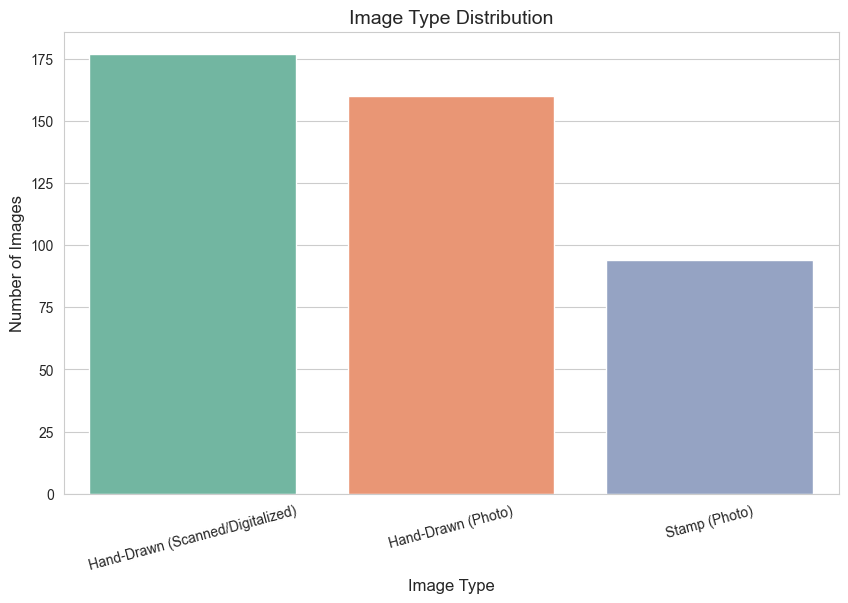

In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(x='image_type', data=data_df, palette="Set2", hue='image_type')
plt.title("Image Type Distribution", fontsize=14)
plt.xlabel("Image Type", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=15)
plt.show()


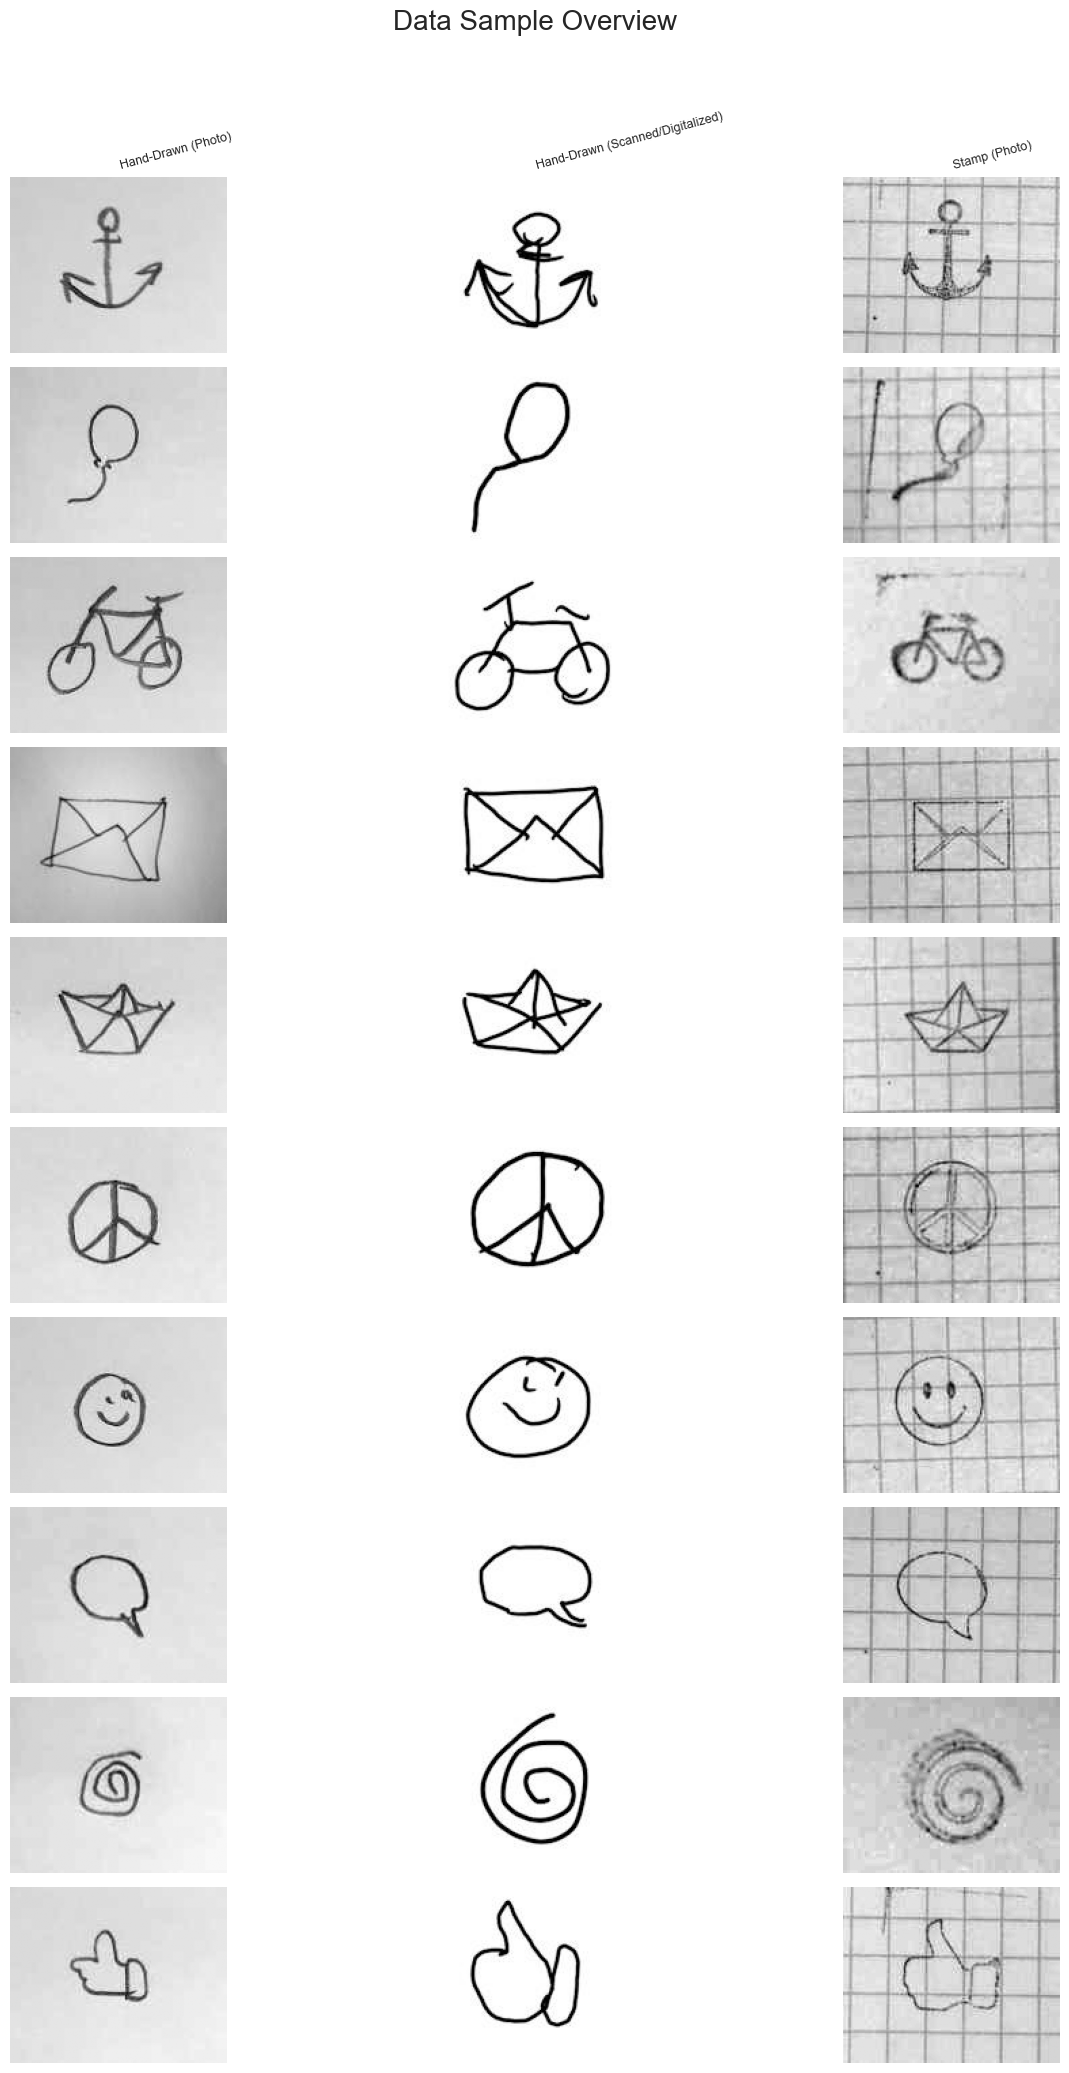

In [5]:
classes = sorted(data_df["class_name"].unique())
image_types = sorted(data_df["image_type"].unique())

fig, axes = plt.subplots(len(classes), len(image_types), figsize=(14, 2 * len(classes)))
fig.suptitle("Data Sample Overview", fontsize=20, y=1.03)

for i, class_name in enumerate(classes):
    for j, img_type in enumerate(image_types):
        ax = axes[i, j]

        if i == 0:
            ax.set_title(img_type, fontsize=9, rotation=15, ha='left')
        if j == 0:
            ax.set_ylabel(class_name, rotation=0, fontsize=12, labelpad=40)

        sample = data_df[
            (data_df["class_name"] == class_name) &
            (data_df["image_type"] == img_type)
        ].head(1)

        if not sample.empty:
            img = Image.open(sample["filepath"].iloc[0])
            ax.imshow(img, cmap='gray')

        ax.axis("off")

plt.tight_layout(pad=0.5, h_pad=1.0)
plt.show()


In [6]:
train_loader, val_loader, test_loader, test_df = get_dataloaders(
    data_df, GLOBAL_CLASS_TO_IDX, BATCH_SIZE
)

print(f"Number of samples in training set: {len(train_loader.dataset)}")
print(f"Number of samples in validation set: {len(val_loader.dataset)}")
print(f"Number of samples in test set: {len(test_loader.dataset)}")
print(f"\nNumber of batches in test loader: {len(test_loader)}")

Number of samples in training set: 344
Number of samples in validation set: 43
Number of samples in test set: 44

Number of batches in test loader: 2


In [7]:
model = create_model(NUM_CLASSES)

try:
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    print(f"Successfully loaded model weights from '{MODEL_PATH}'")
except FileNotFoundError:
    print(f"ERROR: Weight file '{MODEL_PATH}' not found.")
    print("Please run 'run_pipeline.py' first to train the model.")


Successfully loaded model weights from 'best_model_weights.pth'


--- Overall Classification Report (Test Set) ---
               precision    recall  f1-score   support

       anchor       1.00      1.00      1.00         5
      balloon       1.00      1.00      1.00         4
      bicycle       1.00      1.00      1.00         5
     envelope       1.00      1.00      1.00         5
   paper_boat       1.00      1.00      1.00         4
 peace_symbol       1.00      1.00      1.00         4
       smiley       1.00      0.75      0.86         4
speech_bubble       1.00      1.00      1.00         4
       spiral       0.80      1.00      0.89         4
        thumb       1.00      1.00      1.00         5

     accuracy                           0.98        44
    macro avg       0.98      0.97      0.97        44
 weighted avg       0.98      0.98      0.98        44


Generating confusion matrix...


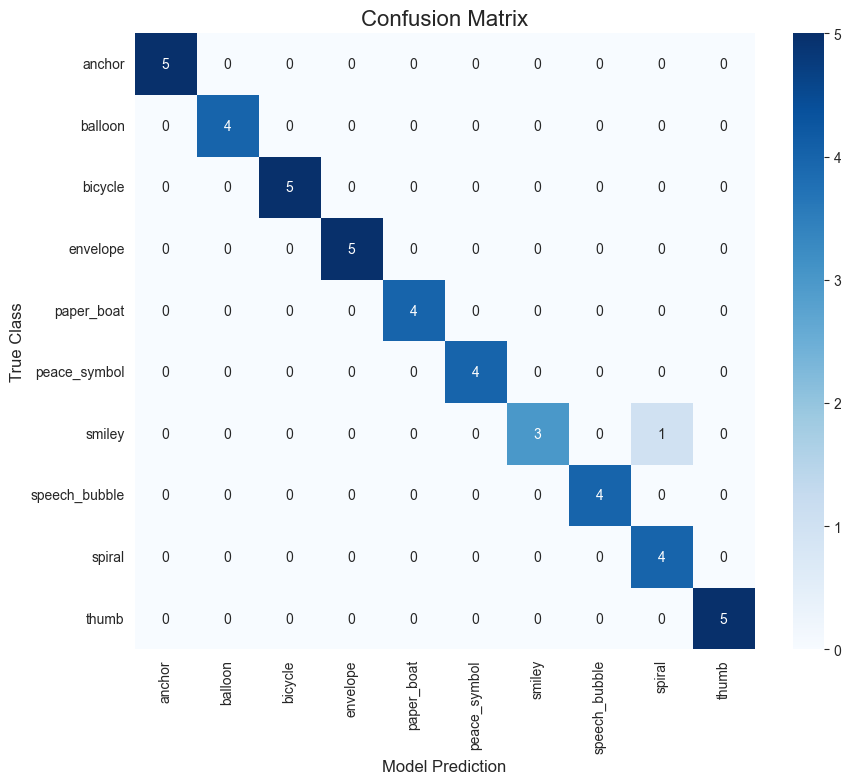

In [8]:
all_labels, all_preds, report, target_names = evaluate_subset(
    test_loader, model, DEVICE, NUM_CLASSES, GLOBAL_CLASS_TO_IDX
)

print("--- Overall Classification Report (Test Set) ---")
print(report)

print("\nGenerating confusion matrix...")
plot_confusion_matrix(all_labels, all_preds, target_names)
plt.show()

In [9]:
test_hand_drawn_df = test_df[test_df['image_type'].str.contains('Hand-Drawn')].reset_index(drop=True)
test_stamp_df = test_df[test_df['image_type'].str.contains('Stamp')].reset_index(drop=True)

val_test_transforms = transforms.Compose([
    transforms.Resize((130, 160)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

loader_hand_drawn = get_subset_loader(test_hand_drawn_df, val_test_transforms, GLOBAL_CLASS_TO_IDX, BATCH_SIZE)
loader_stamp = get_subset_loader(test_stamp_df, val_test_transforms, GLOBAL_CLASS_TO_IDX, BATCH_SIZE)

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT: HAND-DRAWN IMAGES")
print("=" * 60)

_, _, report_hd, _ = evaluate_subset(loader_hand_drawn, model, DEVICE, NUM_CLASSES, GLOBAL_CLASS_TO_IDX)
print(report_hd)

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT: STAMP / GRAPHIC IMAGES")
print("=" * 60)

_, _, report_st, _ = evaluate_subset(loader_stamp, model, DEVICE, NUM_CLASSES, GLOBAL_CLASS_TO_IDX)
print(report_st)



CLASSIFICATION REPORT: HAND-DRAWN IMAGES
               precision    recall  f1-score   support

       anchor       1.00      1.00      1.00         3
      balloon       1.00      1.00      1.00         4
      bicycle       1.00      1.00      1.00         4
     envelope       1.00      1.00      1.00         5
   paper_boat       1.00      1.00      1.00         2
 peace_symbol       1.00      1.00      1.00         3
       smiley       1.00      0.75      0.86         4
speech_bubble       1.00      1.00      1.00         4
       spiral       0.75      1.00      0.86         3
        thumb       1.00      1.00      1.00         4

     accuracy                           0.97        36
    macro avg       0.97      0.97      0.97        36
 weighted avg       0.98      0.97      0.97        36


CLASSIFICATION REPORT: STAMP / GRAPHIC IMAGES
               precision    recall  f1-score   support

       anchor       1.00      1.00      1.00         2
      balloon       0.00   

Generating visualization of 10 random predictions...


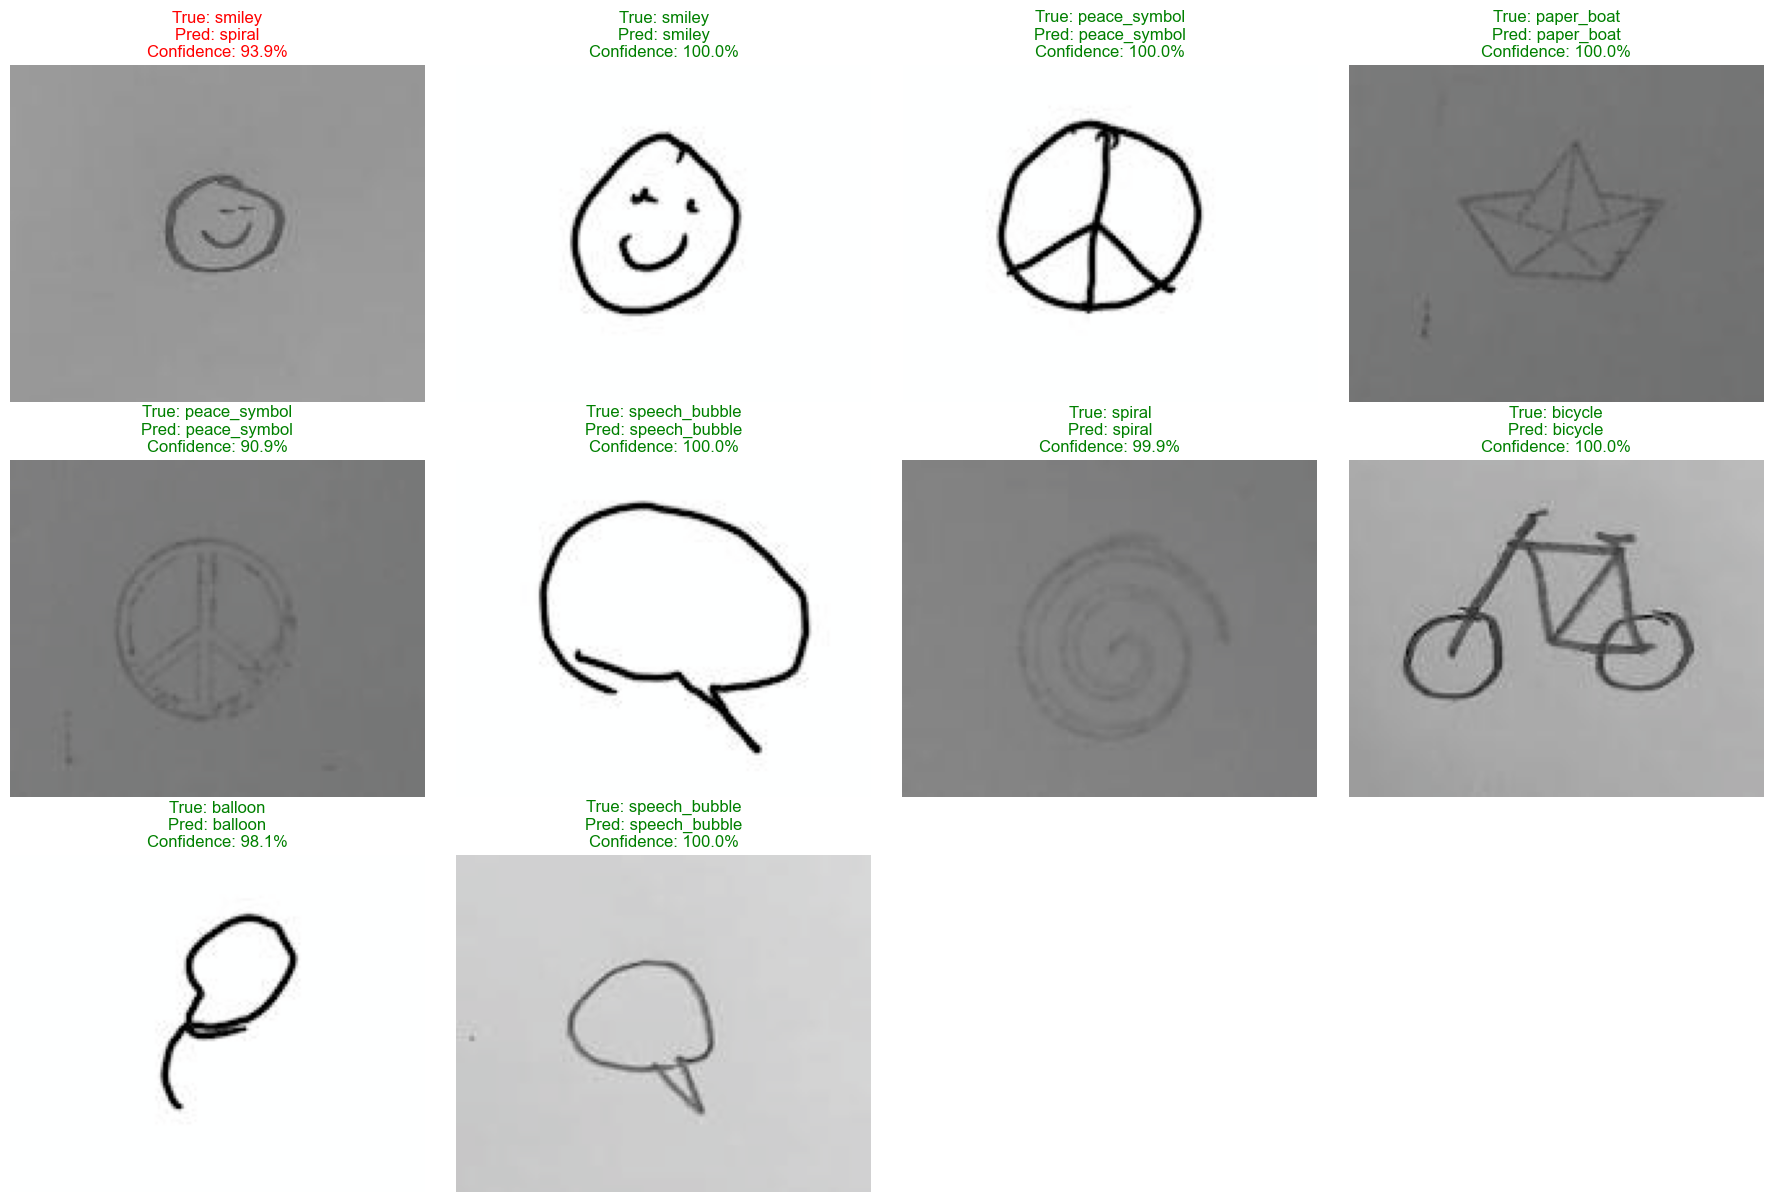

In [10]:
%load_ext autoreload
%autoreload 2
print("Generating visualization of 10 random predictions...")
visualize_model_predictions(model, test_loader, DEVICE, GLOBAL_CLASS_TO_IDX, num_images=10)

Successfully loaded training history from 'train_history.json'.


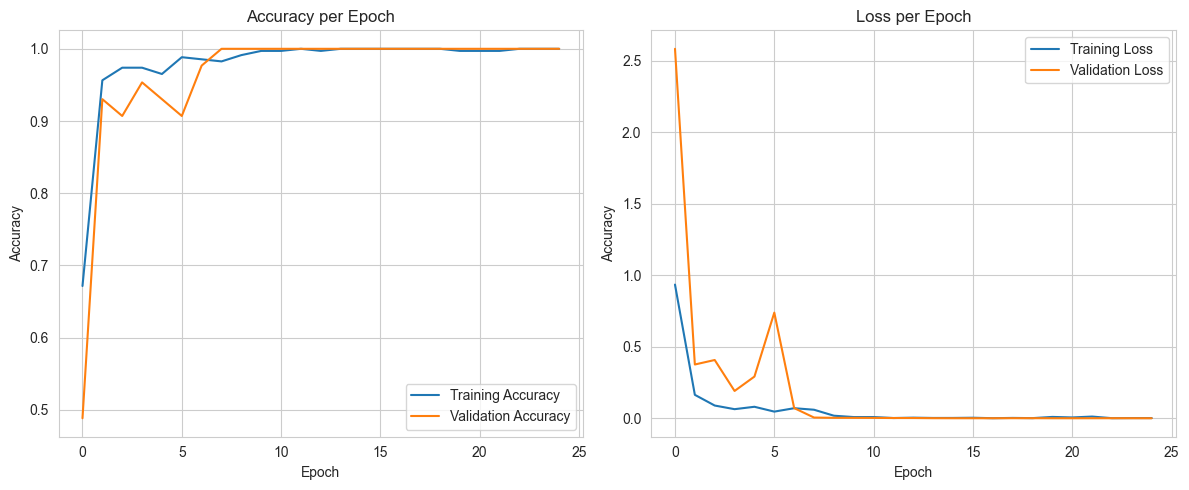

In [11]:
history_path = 'train_history.json'

try:
    with open(history_path, 'r') as f:
        history = json.load(f)

    print(f"Successfully loaded training history from '{history_path}'.")

    plot_metrics(history)
    plt.show()

except FileNotFoundError:
    print(f"ERROR: File '{history_path}' not found.")
    print("To generate this plot, you must first run the training:")
    print("In the terminal, run: python run_pipeline.py --force-train")
except Exception as e:
    print(f"An error occurred while loading or plotting the history: {e}")

Generating Grad-CAM for a random test image (Index 0)...


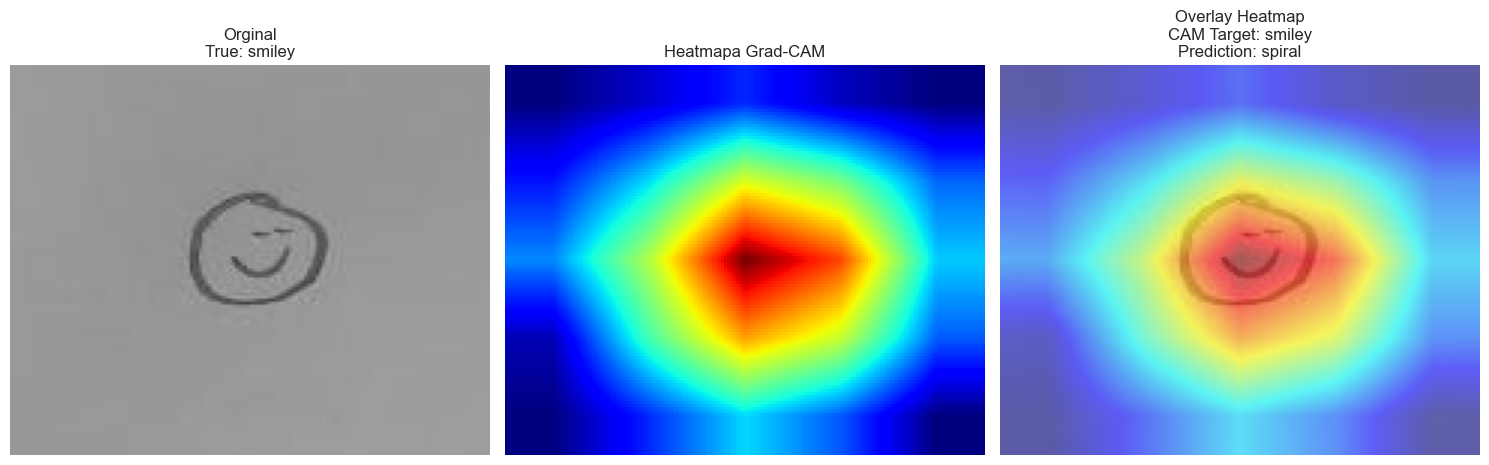


Generating Grad-CAM for a potential misclassified image (Index 9)...


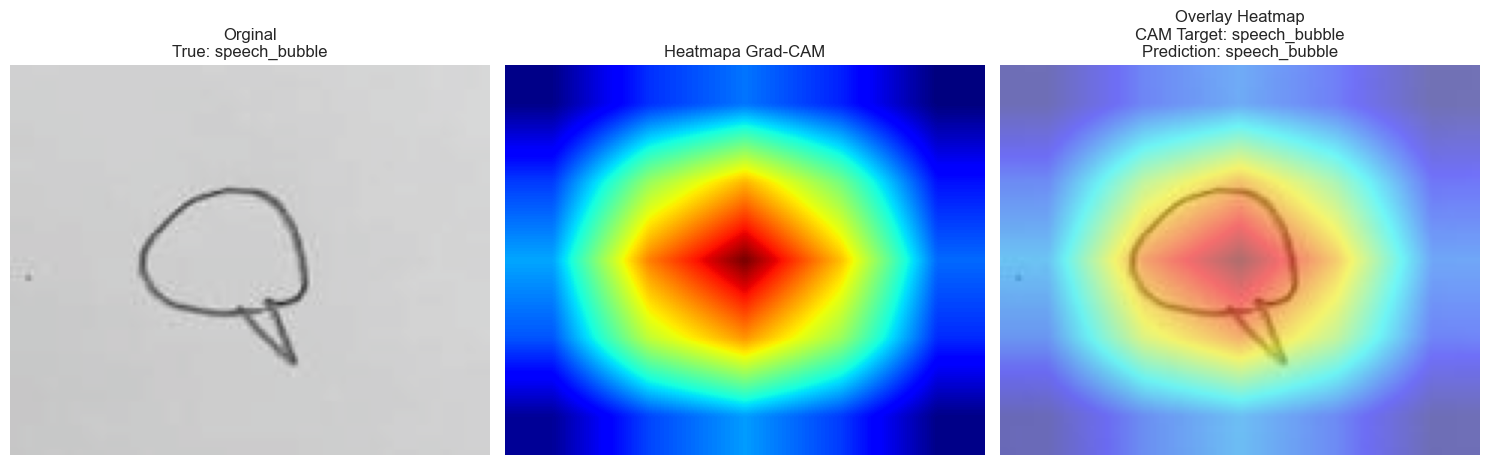

In [12]:
try:
    target_layer_to_use = model.layer4[-1]

    print("Generating Grad-CAM for a random test image (Index 0)...")
    plot_grad_cam(model, target_layer_to_use, test_loader, DEVICE, GLOBAL_CLASS_TO_IDX, img_index=0)

    print("\nGenerating Grad-CAM for a potential misclassified image (Index 9)...")
    plot_grad_cam(model, target_layer_to_use, test_loader, DEVICE, GLOBAL_CLASS_TO_IDX, img_index=9)

except NameError:
    print("ERROR: 'plot_grad_cam' not found. Make sure to restart the kernel after saving src/evaluate.py!")
except Exception as e:
    print(f"An error occurred: {e}")
